# Exploratory Notebook: Integrating River Data Into Training


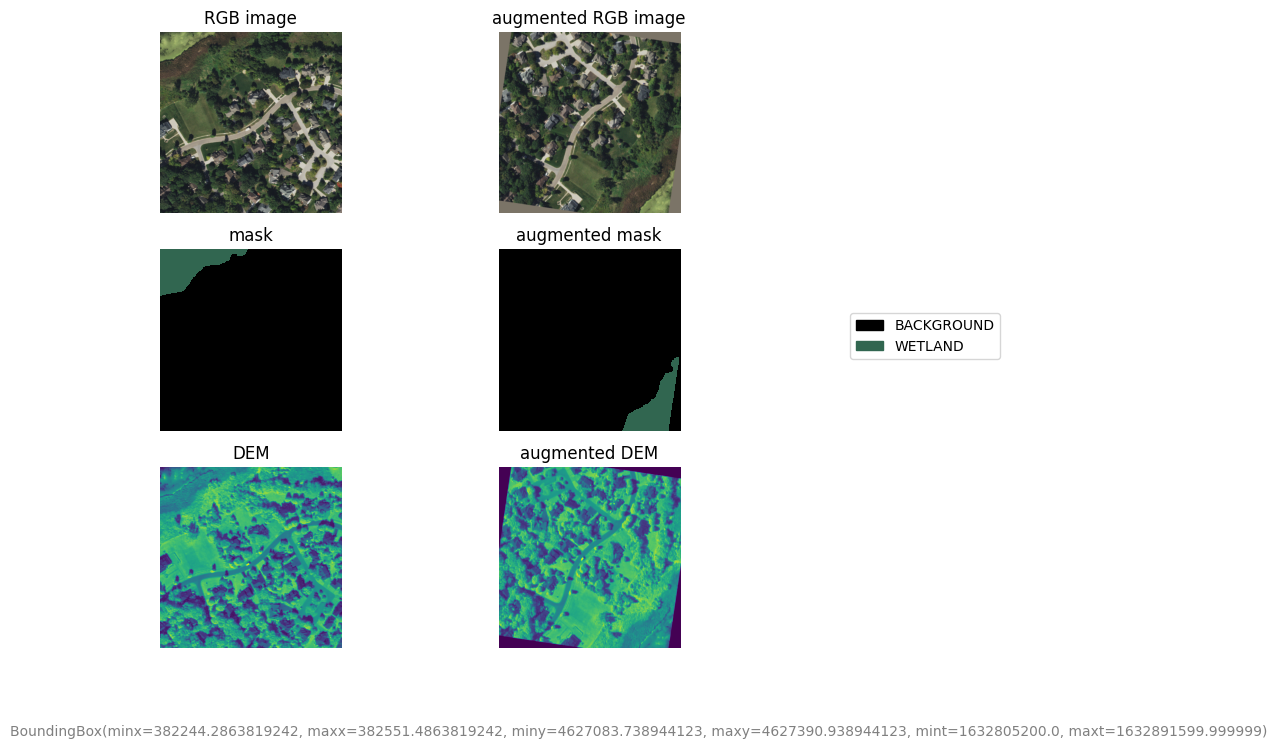

Error: no "view" rule for type "image/png" passed its test case
       (for more information, add "--debug=1" on the command line)


In [ ]:
from PIL import Image

# Path to your image
image_path = "/net/projects/cmap/workspaces/annapoon/testing_rd_train_1_trial_0/train-images/epoch-4/train_sample-4.15.png"

# Open and display the image
img = Image.open(image_path)

from IPython.display import display
display(img)
img.show()


In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
# RIVER DATASET
from pathlib import Path
import sys
from rd import RiverDataset
import torch
from torchgeo.datasets import BoundingBox
import sys
import os

# Example configuration for the dataset
rd_configs = (
    {5: "STREAM/RIVER", 0: "UNKNOWN"},  # Label mapping
    256,  # Patch size
    "EPSG:4326",  # Destination CRS
    0.1,  # Resolution in CRS units
)

rd_path = "/net/projects/cmap/data/kane-county-data/Kane_Co_Open_Water_Layer.zip"

# Create RiverDataset instance with both KC and river data
river_dataset = RiverDataset(rd_path, rd_configs, kc=True)

# Access the combined dataset
print(river_dataset.gdf.head())

Initial Kane County GeoDataFrame loaded:
           BasinType                                           geometry
0               POND  MULTIPOLYGON (((945992.273 1935539.526, 945981...
1  DRY BOTTOM - TURF  MULTIPOLYGON (((957439.997 1930555.492, 957416...
2               POND  MULTIPOLYGON (((947040.816 1927034.962, 947028...
3               POND  MULTIPOLYGON (((948408.045 1926341.826, 948397...
4               POND  MULTIPOLYGON (((947424.509 1925889.426, 947443...
Kane countys filtered gdf
           BasinType                                           geometry
0               POND  MULTIPOLYGON (((-88.47404 41.98057, -88.47408 ...
1  DRY BOTTOM - TURF  MULTIPOLYGON (((-88.43192 41.96693, -88.43200 ...
2               POND  MULTIPOLYGON (((-88.47013 41.95723, -88.47018 ...
3               POND  MULTIPOLYGON (((-88.46510 41.95534, -88.46514 ...
4               POND  MULTIPOLYGON (((-88.46872 41.95409, -88.46865 ...
Initialized KC dataset with (4, {'BACKGROUND': 0, 'POND': 1, 'WETLAND

Processing x-axis:   1%|▏         | 73/5304 [00:30<36:33,  2.38it/s]  


Total chips inserted: 7734
Initialized RiverDataset with configs: ({5: 'STREAM/RIVER', 0: 'UNKNOWN'}, 256, 'EPSG:4326', 0.1)
    OBJECTID_1  OBJECTID         FCODE AddUser AddDate      EditUser  \
4          7.0       7.0  STREAM/RIVER    None    None          None   
6          9.0       9.0  STREAM/RIVER    None    None          None   
23        33.0      33.0  STREAM/RIVER    None    None  EDITORGISJCV   
64       106.0     119.0  STREAM/RIVER    None    None          None   
65       107.0     120.0  STREAM/RIVER    None    None          None   

      EditDate    Shape_STAr     Shape_STLe  \
4         None  1.172604e+04    1275.191296   
6         None  2.128186e+05   19090.189595   
23  2023-06-26  8.174566e+07  680059.514125   
64        None  3.944582e+03     497.472119   
65        None  1.295572e+03     173.314525   

                                             geometry     BasinType  
4   POLYGON ((-88.26169 41.73687, -88.26169 41.736...  STREAM/RIVER  
6   POLYGON ((-88.2

Setting plot limits: minx=-88.60247504118747, miny=41.71979852550066, maxx=-88.2374750411878, maxy=42.154953128022356
Plot X Limits: (-88.60247504118747, -88.2374750411878)
Plot Y Limits: (41.71979852550066, 42.154953128022356)


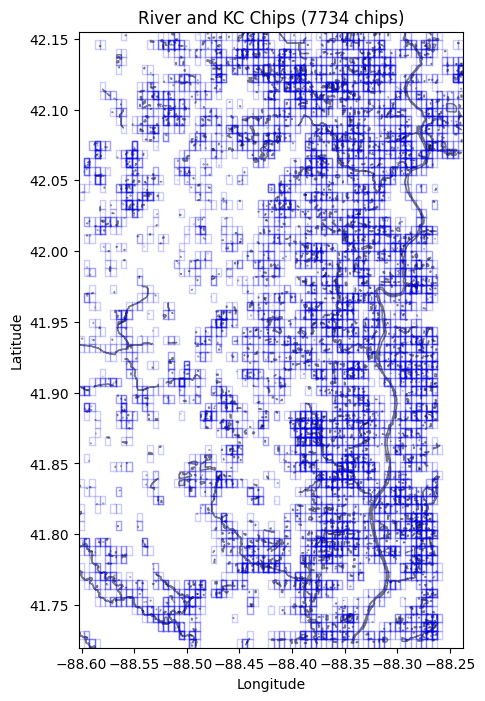

river chip count: 7734


In [11]:
import matplotlib.pyplot as plt
from shapely.geometry import box

# Create a new figure
fig, ax = plt.subplots(figsize=(6, 8))  # Adjust the second value to make it taller

# Plot the geometries in river_dataset.gdf
# Assuming 'geometry' column contains geometries of the river polygons
river_dataset.gdf.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.5)

# Initialize the river counter
river_counter = 0

# Initialize limits for plotting based on chips
minx_plot, miny_plot, maxx_plot, maxy_plot = float('inf'), float('inf'), -float('inf'), -float('inf')

# Loop through the R-tree index and extract bounding box coordinates
for item in river_dataset.index.intersection(river_dataset.index.bounds, objects=True):
    # Check the structure of item.bbox to understand the extra values
    #print(f"Item BBox: {item.bbox}")
    
    # Assuming bbox contains extra data, extracting the expected (minx, maxx, miny, maxy) values
    # Accessing the coordinates according to your custom index structure
    minx, maxx, miny, maxy = item.bbox[0], item.bbox[1], item.bbox[3], item.bbox[4]
    bbox = [minx, miny, maxx, maxy]
    
    # Ensure bbox has valid coordinates (minx, miny, maxx, maxy)
    if len(bbox) == 4:
        # Update plot limits dynamically based on chip bounding boxes
        minx_plot = min(minx_plot, minx)
        miny_plot = min(miny_plot, miny)
        maxx_plot = max(maxx_plot, maxx)
        maxy_plot = max(maxy_plot, maxy)
        
        # Create a rectangle (chip) for the bounding box using Shapely
        chip = box(minx, miny, maxx, maxy)  # Create a chip using the custom bounding box
        
        # Extract the exterior coordinates of the chip (polygon)
        x, y = chip.exterior.xy
        
        # Plot the bounding box
        ax.plot(x, y, 'b-', lw=1, alpha=0.2)  # Plot using the exterior coordinates
        
        # Increment the counter
        river_counter += 1
    else:
        print(f"Skipping item with invalid bbox: {bbox}")

# Set plot limits based on the min/max of the bounding boxes
print(f"Setting plot limits: minx={minx_plot}, miny={miny_plot}, maxx={maxx_plot}, maxy={maxy_plot}")
ax.set_xlim(minx_plot, maxx_plot)
ax.set_ylim(miny_plot, maxy_plot)

# Double-check the limits to make sure they're correct:
print(f"Plot X Limits: {ax.get_xlim()}")
print(f"Plot Y Limits: {ax.get_ylim()}")

# Add titles and labels
ax.set_title(f"River and KC Chips ({river_counter} chips)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Show the plot
plt.show()

# Print the total number of chips
print("river chip count:", river_counter)
    
    

In [14]:
from rtree import index

rd_counter = 0

for item in river_dataset.index.intersection(river_dataset.index.bounds, objects=True):
    #print(f"ID: {item.id}, Bounds: {item.bbox}, row: {item.object}")
    rd_counter += 1
    kc_bbox = item.bbox

print("kc and rd chip count:", rd_counter)

kc and rd chip count: 7734
